# CARE: Time-series waveforms

Select a wind farm and event ID to view sensor waveforms with **Matplotlib**.
This notebook includes static figures generated from real data, so they are visible in GitHub previews.

- The default selection is **Wind Farm A, event 0**. Edit the selection cell and rerun the following cells.
- Previously downloaded data is read from the configured `data_root`. No datasets are downloaded automatically.
- The full recording and the prediction detail are shown separately. Each sensor has its own vertical axis, and all rows of the selected signals are plotted.
- Yellow shading indicates the `prediction` interval; red shading indicates the provider's event interval. Timestamps are anonymized.

Select the repository's **Python (pdmdata)** kernel to run this notebook.

In [1]:
from pathlib import Path
from datetime import timedelta
import sys

ROOT = next(
    path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "pdmdata.toml").is_file() and (path / "pdmdata").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display
import pdmdata
from pdmdata.care.viz import plot_waveforms

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150})

## 1. Select the data

Set `WIND_FARM` to `"A"`, `"B"`, or `"C"`, and choose `EVENT_ID` from the event table below.
With `SIGNALS = None`, the first four average sensor columns are selected.
For example, for Wind Farm A you can use `SIGNALS = ["wind_speed_3_avg", "power_29_avg", "sensor_5_avg"]`.
Column names and units differ between wind farms.

In [2]:
WIND_FARM = "A"
EVENT_ID = 0
SIGNALS = None
CONTEXT_DAYS = 7  # Days of context before the prediction interval

# Save under the Git-ignored data/ directory. Change this path if needed.
OUTPUT_DIR = ROOT / "data" / "figures" / "care"

In [3]:
events = pdmdata.load("care", wind_farm=WIND_FARM, table="events", lazy=False)
with pl.Config(tbl_rows=100):
    display(events.select("event_id", "asset_id", "event_label", "event_start", "event_end").sort("event_id"))

event_id,asset_id,event_label,event_start,event_end
i64,i64,str,datetime[μs],datetime[μs]
0,0,"""anomaly""",2023-08-06 06:10:00,2023-08-20 06:10:00
3,10,"""normal""",2023-04-27 03:00:00,2023-05-18 01:10:00
10,10,"""anomaly""",2023-10-11 08:40:00,2023-10-18 08:40:00
13,21,"""normal""",2023-05-03 13:20:00,2023-05-24 10:20:00
14,13,"""normal""",2023-03-05 14:00:00,2023-03-12 18:40:00
17,10,"""normal""",2023-11-02 15:20:00,2023-11-16 00:40:00
22,21,"""anomaly""",2023-08-12 09:50:00,2023-08-19 10:00:00
24,0,"""normal""",2023-04-27 15:00:00,2023-05-11 11:20:00
25,11,"""normal""",2023-05-23 06:50:00,2023-06-05 02:30:00


## 2. Load and inspect the recording

Raw CSV files are not modified. The `train_test` column distinguishes `train` from `prediction`;
it is not an anomaly label. Consult the event table for event labels.

In [4]:
record = events.filter(pl.col("event_id") == EVENT_ID)
if record.height != 1:
    raise ValueError(f"Event {EVENT_ID} is not available in Wind Farm {WIND_FARM}. Select an event from the table above.")
event = record.row(0, named=True)
frame = pdmdata.load("care", wind_farm=WIND_FARM, event_id=EVENT_ID)
schema = frame.collect_schema()
signals = SIGNALS if SIGNALS is not None else [
    name for name, dtype in schema.items()
    if name.endswith("_avg") and dtype.is_numeric()
][:4]
print("Signals:", signals)
display(record)
display(frame.group_by("train_test").agg(
    pl.len().alias("rows"),
    pl.col("time_stamp").min().alias("start"),
    pl.col("time_stamp").max().alias("end"),
).sort("start").collect())

Signals: ['sensor_0_avg', 'sensor_1_avg', 'sensor_2_avg', 'wind_speed_3_avg']


asset_id,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description
i64,i64,str,datetime[μs],i64,datetime[μs],i64,str
0,0,"""anomaly""",2023-08-06 06:10:00,52436,2023-08-20 06:10:00,54447,"""Generator bearing failure"""


train_test,rows,start,end
str,u32,datetime[μs],datetime[μs]
"""train""",52148,2022-08-04 06:10:00,2023-08-04 06:00:00
"""prediction""",2838,2023-08-04 06:10:00,2023-08-24 06:10:00


In [5]:
features = pdmdata.load("care", wind_farm=WIND_FARM, table="features", lazy=False)
sensor_names = [name.rsplit("_", 1)[0] if name.endswith(("_avg", "_min", "_max", "_std")) else name for name in signals]
display(features.filter(pl.col("sensor_name").is_in(sensor_names)))

sensor_name,statistics_type,description,unit,is_angle,is_counter
str,str,str,str,bool,bool
"""sensor_0""","""average""","""Ambient temperature""","""�C""",false,false
"""sensor_1""","""average""","""Wind absolute direction""","""�""",true,false
"""sensor_2""","""average""","""Wind relative direction""","""�""",true,false
"""wind_speed_3""","""maximum,minimum,average,std_de…","""Windspeed""","""m/s""",false,false


## 3. Full-recording waveforms

All observations across the full recording are plotted, without truncation or downsampling.
Vertical axes show original values. Sensor scales differ, so their amplitudes should not be compared directly.

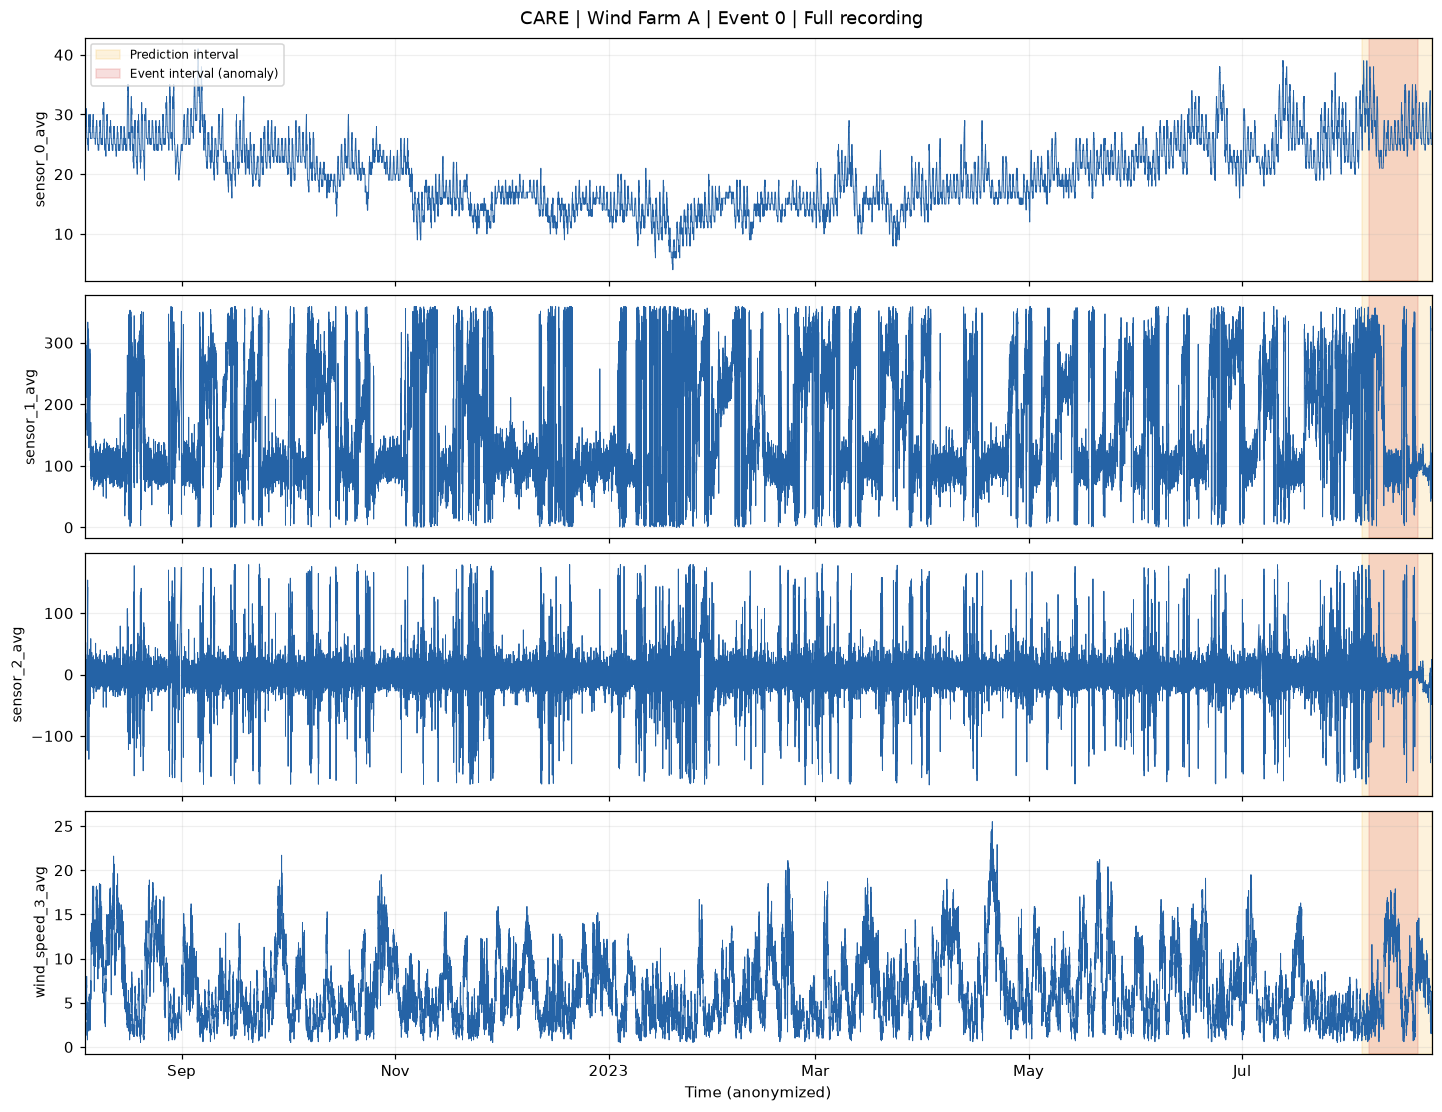

In [6]:
overview = plot_waveforms(
    frame, columns=signals, event=event,
    title=f"CARE | Wind Farm {WIND_FARM} | Event {EVENT_ID} | Full recording",
)
plt.show()

## 4. Prediction detail

Show the period from `CONTEXT_DAYS` before the prediction interval begins through the end of the recording.
To inspect a different period, apply additional timestamp conditions with `frame.filter(...)` before plotting.

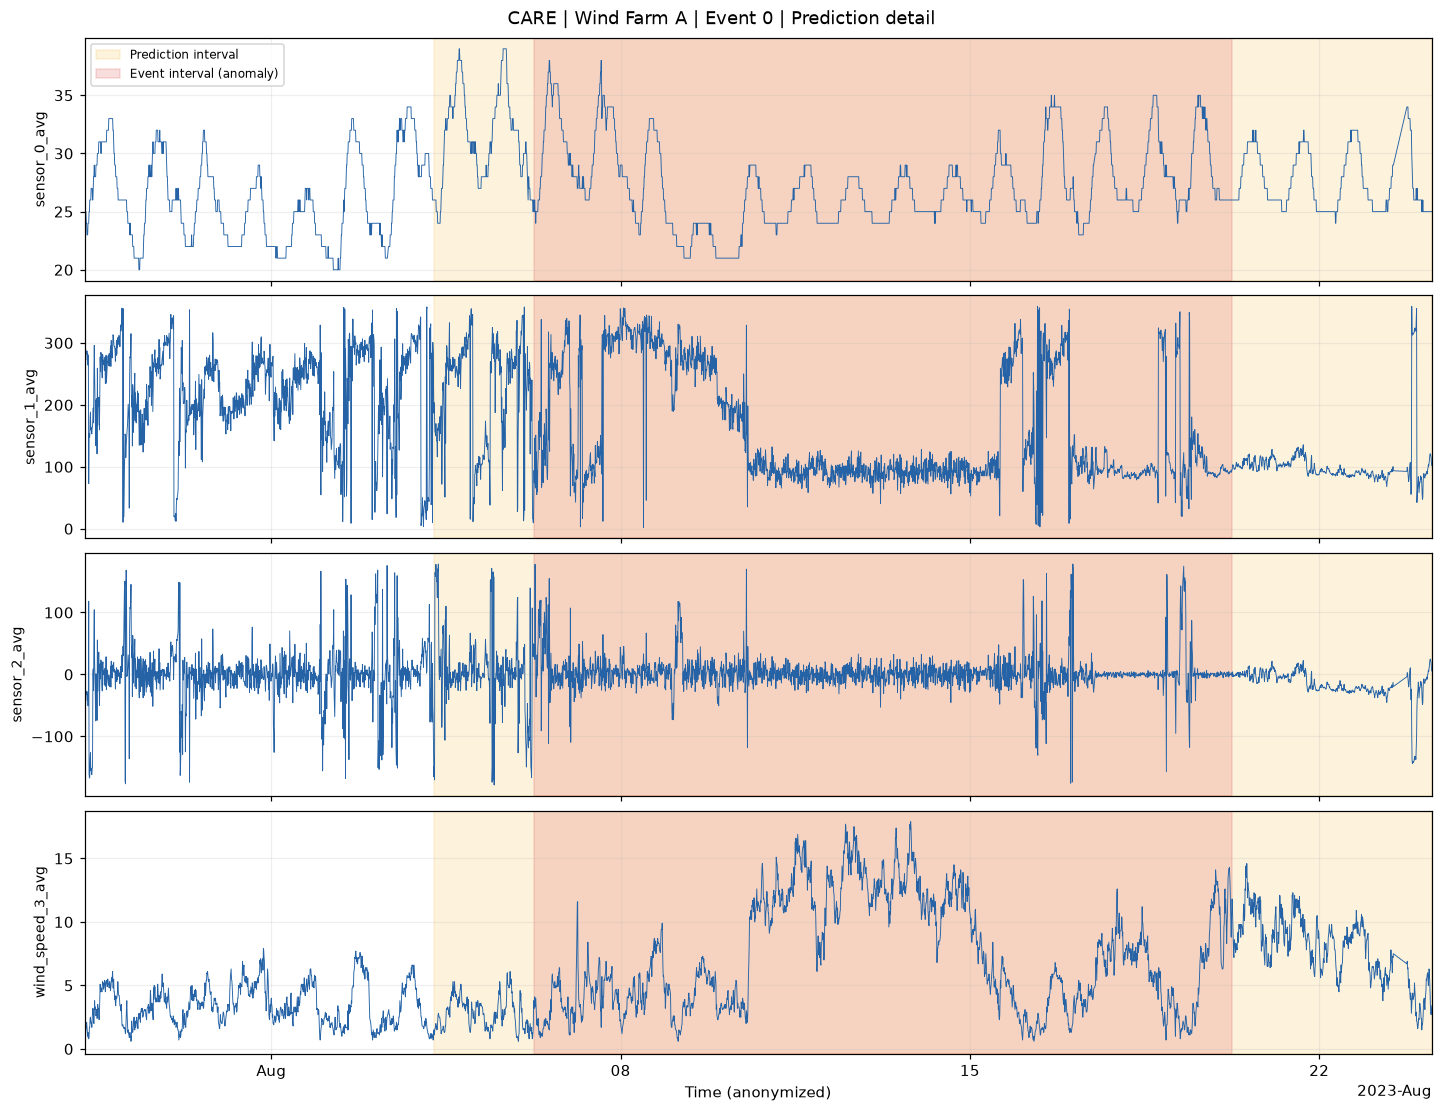

In [7]:
prediction_start = frame.filter(pl.col("train_test") == "prediction").select(
    pl.col("time_stamp").min()
).collect().item()
if prediction_start is None:
    raise ValueError("The selected recording has no prediction interval.")
focus = frame.filter(pl.col("time_stamp") >= prediction_start - timedelta(days=CONTEXT_DAYS))
detail = plot_waveforms(
    focus, columns=signals, event=event,
    title=f"CARE | Wind Farm {WIND_FARM} | Event {EVENT_ID} | Prediction detail",
)
plt.show()

## 5. Save the figures

Save the figures as PNG files. Images are also stored in the notebook outputs for static viewing on GitHub.
Interactive Plotly figures do not work in GitHub's standard notebook preview.
[GitHub documentation](https://docs.github.com/en/repositories/working-with-files/using-files/working-with-non-code-files#working-with-jupyter-notebook-files-on-github)

CARE has known inconsistencies in Min / Max / Std statistics. This example uses Avg columns.
The provider particularly recommends Avg measurements for analyses of Wind Farm B.
[CARE source](https://zenodo.org/records/15846963)

In [8]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
stem = f"care_{WIND_FARM}_{EVENT_ID}"
overview.savefig(OUTPUT_DIR / f"{stem}_overview.png", bbox_inches="tight")
detail.savefig(OUTPUT_DIR / f"{stem}_detail.png", bbox_inches="tight")
print(f"Saved {stem}_overview.png and {stem}_detail.png")

Saved care_A_0_overview.png and care_A_0_detail.png
